In [1]:
library(zellkonverter)
library(SingleCellExperiment)
library(miloR)
library(scater)
library(scran)
library(Matrix)
library(dplyr)
library (ggplot2)
library(gridExtra)

set.seed(33)

outdir = "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo"


Registered S3 method overwritten by 'zellkonverter':
  method                                             from      
  py_to_r.pandas.core.arrays.categorical.Categorical reticulate

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,


In [2]:
cd8_agexsex <- readH5AD("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_miloR.h5ad")

In [3]:
print(cd8_agexsex)
print(dim(cd8_agexsex))

print(colnames(colData(cd8_agexsex)))
print(head(as.data.frame(colData(cd8_agexsex))))

print(assayNames(cd8_agexsex))

class: SingleCellExperiment 
dim: 38606 265568 
metadata(0):
assays(1): X
rownames(38606): DDX11L2 MIR1302-2HG ... ENSG00000278817
  ENSG00000277196
rowData names(6): gene_ids feature_types ... ribo hb
colnames(265568):
  20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC
  20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAGGCTTCA
  ...
  20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGTCTTCGCGTGCA
  20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGTGCAGAAGCTAA
colData names(4): pica_id ageyrs sex batch
reducedDimNames(2): X_scVI X_umap
mainExpName: NULL
altExpNames(0):
[1]  38606 265568
[1] "pica_id" "ageyrs"  "sex"     "batch"  
                                                                    pica_id
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC PICA0022
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAGGCTTCA PICA0022
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCATGGCGT PICA0022
20240918_WGS_20240924

In [4]:
table(colData(cd8_agexsex)$sex)
table(colData(cd8_agexsex)$batch)
summary(colData(cd8_agexsex)$ageyrs)
length(unique(colData(cd8_agexsex)$pica_id))
table(colData(cd8_agexsex)$pica_id)[1:10]


Female   Male 
113531 152037 


Batch01 Batch02 Batch03 Batch04 Batch05 Batch06 Batch07 
   3944   46226   50717   54068   31334   48055   31224 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.050   4.460   7.510   8.358  12.720  17.030 

[1] 128


PICA0001 PICA0002 PICA0003 PICA0004 PICA0005 PICA0006 PICA0007 PICA0008 
     716      396      441      393      484      663      851     2902 
PICA0009 PICA0010 
    2790      585 

In [5]:
# check for missing calues
colSums(is.na(colData(cd8_agexsex)[, c("pica_id", "ageyrs", "sex", "batch")]))

[1] 0 0 0 0

In [6]:
#clean metadata
meta <- as.data.frame(colData(cd8_agexsex))
meta$pica_id <- as.character(meta$pica_id)
meta$ageyrs <- as.numeric(meta$ageyrs)
meta$sex <- factor(meta$sex)
meta$batch <- factor(meta$batch)

# define reference level
meta$sex <- relevel(meta$sex, ref = "Female")

# put cleaned metadata back into object
colData(cd8_agexsex) <- S4Vectors::DataFrame(meta)


## Prepare milo object

In [7]:
# build milo object
milo <- Milo(cd8_agexsex)

latent_dim <- min(20, ncol(reducedDim(milo, "X_scVI")))

milo <- buildGraph(
  milo,
  k = 30,
  d = latent_dim,
  reduced.dim = "X_scVI"
)

Constructing kNN graph with k:30



In [8]:
milo <- makeNhoods(
  milo,
  prop = 0.1,
  k = 30,
  d = latent_dim,
  refined = TRUE,
  reduced_dims = "X_scVI"
)

Checking valid object

Running refined sampling with reduced_dim



[1] 265568  25167

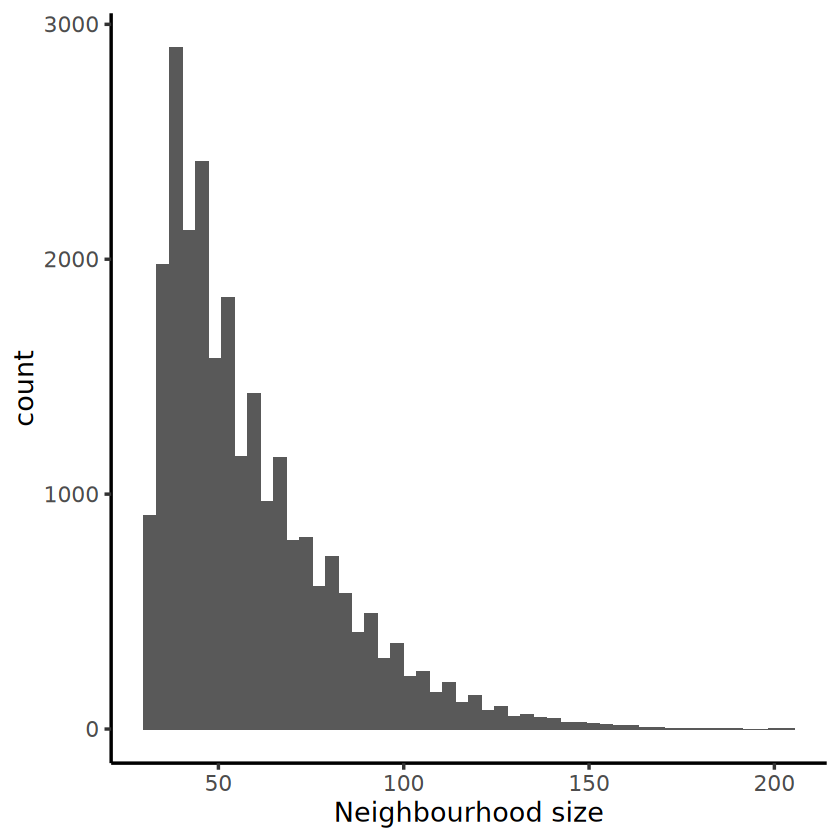

In [9]:
dim(nhoods(milo))
plotNhoodSizeHist(milo)

In [ ]:
t1 <- Sys.time()
milo <- calcNhoodDistance(
  milo,
  d = 20,
  reduced.dim = "X_scVI"
)
t2 <- Sys.time()
print(difftime(t2, t1, units = "mins"))

In [ ]:
saveRDS(milo, "milo_with_distances.rds")

In [ ]:
# count cells per sample
milo <- countCells(
  milo,
  meta.data = as.data.frame(colData(milo)),
  samples = "pica_id"
)

print(dim(nhoodCounts(milo)))

In [ ]:
# build donor-level design dataframe
design_df <- as.data.frame(colData(milo)) %>%
  dplyr::select(pica_id, ageyrs, sex, batch) %>%
  distinct()

rownames(design_df) <- design_df$pica_id
design_df <- design_df[colnames(nhoodCounts(milo)), , drop = FALSE]

In [ ]:
design_df$sex <- factor(design_df$sex)
design_df$batch <- factor(design_df$batch)
design_df$sex <- relevel(design_df$sex, ref = "Female")

In [ ]:
cat("\n===== FINAL DESIGN DF =====\n")
print(head(design_df))

cat("\n===== FINAL MODEL MATRIX COLUMNS =====\n")
mm <- model.matrix(~ ageyrs * sex + batch, data = design_df)
print(colnames(mm))

## Run milo

In [ ]:
interaction_term <- grep("ageyrs:sex|sex.*:ageyrs", colnames(mm), value = TRUE)
da_cd8_interaction <- testNhoods(
  milo,
  design = ~ ageyrs * sex + batch,
  design.df = design_df,
  model.contrasts = interaction_term,
  fdr.weighting = "k-distance",
  robust = TRUE
)

In [ ]:
cat("\n===== DA RESULTS HEAD =====\n")
print(head(da_cd8_interaction))

cat("\n===== SIGNIFICANT NHOODS (SpatialFDR < 0.1) =====\n")
print(table(da_cd8_interaction$SpatialFDR < 0.1, useNA = "ifany"))


### Annotation

In [ ]:
da_cd8_interaction_anno <- annotateNhoods(
  milo,
  da_cd8_interaction,
  coldata_col = "pica_cell_type_complete_01_gdT_corrected"
)

In [ ]:
head(da_cd8_interaction_anno)
table(da_cd8_interaction_anno$SpatialFDR < 0.1)

### Visualization

In [ ]:
# cell type summary plot
# Relabel low-purity neighbourhoods as Mixed
df_plot <- as.data.frame(da_cd8_interaction_anno)
df_plot$nhood <- rownames(df_plot)
df_plot$sig <- df_plot$SpatialFDR < 0.1
df_plot$nhood_annotation <- as.character(df_plot$nhood_annotation)
df_plot$nhood_annotation[df_plot$nhood_annotation_frac < 0.6] <- "Mixed"
df_plot$nhood_annotation <- factor(df_plot$nhood_annotation)

# Order annotations by median logFC
anno_order <- df_plot %>%
  group_by(nhood_annotation) %>%
  summarise(median_logFC = median(logFC, na.rm = TRUE), .groups = "drop") %>%
  arrange(median_logFC) %>%
  pull(nhood_annotation)

df_plot$nhood_annotation <- factor(df_plot$nhood_annotation, levels = anno_order)

ggplot(df_plot, aes(x = logFC, y = nhood_annotation)) +
  geom_violin(scale = "width", trim = TRUE) +
  geom_point(aes(shape = sig), alpha = 0.6, size = 1.5, position = position_jitter(height = 0.15, width = 0)) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(
    title = "CD8 Milo DA by neighbourhood annotation",
    x = "logFC (interaction effect)",
    y = NULL
  ) +
  theme_classic()

In [ ]:
# Annotation fraction histogram
p_anno_frac <- ggplot(df_plot, aes(x = nhood_annotation_frac)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Neighbourhood annotation fraction",
    x = "Dominant cell-type fraction",
    y = "Number of neighbourhoods"
  ) +
  theme_classic()

print(p_anno_frac)

In [ ]:
# neighbourhood DA UMAP
milo <- buildNhoodGraph(milo)
  plotNhoodGraphDA(
    milo,
    da_cd8_interaction,
    alpha = 0.1,
    layout = "UMAP"
  )

In [ ]:
# p-value histogram
p_pval <- ggplot(df_plot, aes(x = PValue)) +
  geom_histogram(bins = 50) +
  labs(
    title = "Neighbourhood p-value distribution",
    x = "P-value",
    y = "Number of neighbourhoods"
  ) +
  theme_classic()

print(p_pval)

In [ ]:
# logFC vs significance
p_volcano_like <- ggplot(df_plot, aes(x = logFC, y = -log10(SpatialFDR))) +
  geom_point(aes(shape = sig), alpha = 0.7, size = 1.5) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(
    title = "Neighbourhood DA effect size vs significance",
    x = "logFC (age x sex interaction effect)",
    y = "-log10(SpatialFDR)"
  ) +
  theme_classic()

print(p_volcano_like)

In [ ]:
p_beeswarm_like <- ggplot(df_plot, aes(x = logFC, y = nhood_annotation)) +
  geom_violin(scale = "width", trim = TRUE, fill = "grey90") +
  geom_point(
    aes(shape = sig),
    position = position_jitter(height = 0.18, width = 0),
    alpha = 0.6,
    size = 1.4
  ) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(
    title = "CD8 Milo interaction results by neighbourhood annotation",
    x = "logFC (age x sex interaction effect)",
    y = NULL
  ) +
  theme_classic()

print(p_beeswarm_like)

# significant neighbourhood per cell type
sig_counts <- df_plot %>%
  filter(sig) %>%
  count(nhood_annotation) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = anno_order))

p_sig_counts <- ggplot(sig_counts, aes(x = n, y = nhood_annotation)) +
  geom_col() +
  labs(
    title = "Significant neighbourhoods by annotation",
    x = "Count",
    y = NULL
  ) +
  theme_classic()

print(p_sig_counts)

In [ ]:
grid_panel <- gridExtra::grid.arrange(
  p_beeswarm_like,
  p_sig_counts,
  ncol = 2,
  widths = c(3, 1)
)

In [ ]:
# prop significant by cell type
prop_counts <- df_plot %>%
  group_by(nhood_annotation) %>%
  summarise(
    total_nhoods = n(),
    sig_nhoods = sum(sig, na.rm = TRUE),
    prop_sig = sig_nhoods / total_nhoods,
    .groups = "drop"
  ) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = anno_order))

p_prop_sig <- ggplot(prop_counts, aes(x = prop_sig, y = nhood_annotation)) +
  geom_col() +
  labs(
    title = "Proportion of significant neighbourhoods by annotation",
    x = "Proportion significant",
    y = NULL
  ) +
  theme_classic()

print(p_prop_sig)

In [ ]:
top_sig_nhoods <- df_plot %>%
  filter(!is.na(SpatialFDR)) %>%
  arrange(SpatialFDR, desc(abs(logFC))) %>%
  select(
    nhood,
    nhood_annotation,
    nhood_annotation_frac,
    logFC,
    PValue,
    SpatialFDR
  ) %>%
  head(20)

print(top_sig_nhoods)

write.csv(
  top_sig_nhoods,
  file.path(outdir, "cd8_miloR_top30_significant_neighbourhoods.csv"),
  row.names = FALSE
)

In [ ]:
write.csv(
  df_plot,
  file.path(outdir, "cd8_miloR_all_annotated_neighbourhoods.csv"),
  row.names = FALSE
)

In [ ]:
top_enriched <- df_plot %>%
  filter(sig) %>%
  arrange(desc(logFC)) %>%
  head(5)

top_depleted <- df_plot %>%
  filter(sig) %>%
  arrange(logFC) %>%
  head(5)

print(top_enriched[, c("nhood", "nhood_annotation", "logFC", "SpatialFDR")])
print(top_depleted[, c("nhood", "nhood_annotation", "logFC", "SpatialFDR")])

write.csv(
  top_enriched,
  file.path(outdir, "cd8_miloR_top_enriched_neighbourhoods.csv"),
  row.names = FALSE
)

write.csv(
  top_depleted,
  file.path(outdir, "cd8_miloR_top_depleted_neighbourhoods.csv"),
  row.names = FALSE
)
